<a href="https://colab.research.google.com/github/nadroj0-0/Applied-Deep-Learning-COMP019-GROUP/blob/troy/tft.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install -q pytorch-forecasting lightning pandas matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 399.8/399.8 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 853.6/853.6 kB 28.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 159.8/159.8 kB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 40.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 857.3/857.3 kB 32.0 MB/s eta 0:00:00


In [ ]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import lightning.pytorch as pl
from lightning.pytorch.callbacks import EarlyStopping, LearningRateMonitor, ModelCheckpoint

from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.data import GroupNormalizer
from pytorch_forecasting.metrics import QuantileLoss

# reproducibility
pl.seed_everything(42)

# =========================
# CONFIG
# =========================
STORE_ID_TO_USE = "CA_3"
NUM_SERIES_TO_KEEP = 200

MAX_ENCODER_LENGTH = 56
MAX_PREDICTION_LENGTH = 28

BATCH_SIZE = 64
NUM_WORKERS = 2

# 9 quantiles
QUANTILES = [0.005, 0.025, 0.165, 0.25, 0.5, 0.75, 0.835, 0.975, 0.995]

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


In [ ]:
# LOADING THE M5 FILES
sales_url = "https://huggingface.co/datasets/kashif/M5/resolve/main/sales_train_evaluation.csv"
calendar_url = "https://huggingface.co/datasets/kashif/M5/resolve/main/calendar.csv"
prices_url = "https://huggingface.co/datasets/kashif/M5/resolve/main/sell_prices.csv"

sales = pd.read_csv(sales_url)
calendar = pd.read_csv(calendar_url)
prices= pd.read_csv(prices_url)

print("sales shape:", sales.shape)
print("calendar shape:", calendar.shape)
print("prices shape:", prices.shape)

# the TFT model takes the following 3 types of covariates as input:
#
# 1) static features that don't vary with time:
#     -> item_id, store_id, dept_id, etc

# 2) Time varying known inputs e.g that are known in advance e.g. future known
#     -> e.g. date, day of week, month, snap_CA, snap_TX, event_name
#     -> sell_price (if we assume future sell price is known )

# 3) Time varying unknown inputs (i.e only known in th past)
#     -> sales (our target), lagged demand features, anything derived from past observations

# therefore we use pytorchs TimeSeriesDataset which explicitly supports static variables and time varying unknown/known variables

sales shape: (30490, 1947)
calendar shape: (1969, 14)
prices shape: (6841121, 4)


In [ ]:
day_cols = [c for c in sales.columns if c.startswith("d_")]

# keep only one store
sales_store = sales[sales["store_id"] == STORE_ID_TO_USE].copy()

print("rows in selected store:", sales_store.shape)

# rank by total sales volume over all available days
sales_store["total_sales_volume"] = sales_store[day_cols].sum(axis=1)

sales_small = (
    sales_store.sort_values("total_sales_volume", ascending=False)
               .head(NUM_SERIES_TO_KEEP)
               .drop(columns=["total_sales_volume"])
               .copy()
)

print("trimmed sales shape:", sales_small.shape)
print("unique store_ids:", sales_small["store_id"].unique())
print(sales_small[["id", "item_id", "store_id", "state_id"]].head())

# filters down to just CA_3
# computes total sales over all day columns for each item-series in that store
# keeps the top 200
# does not remove any days







rows in selected store: (3049, 1947)
trimmed sales shape: (200, 1947)
unique store_ids: ['CA_3']
                               id      item_id store_id state_id
8412  FOODS_3_090_CA_3_evaluation  FOODS_3_090     CA_3       CA
8908  FOODS_3_586_CA_3_evaluation  FOODS_3_586     CA_3       CA
8442  FOODS_3_120_CA_3_evaluation  FOODS_3_120     CA_3       CA
8574  FOODS_3_252_CA_3_evaluation  FOODS_3_252     CA_3       CA
8863  FOODS_3_541_CA_3_evaluation  FOODS_3_541     CA_3       CA


In [ ]:
# MELT WIDE SALES INTO LONG FORMAT


# FILTER FOR ONLY C3,
id_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

sales_long = sales_small.melt(
    id_vars = id_cols,
    value_vars = day_cols,
    var_name ="d",
    value_name="sales"
)

print("sales_long shape:", sales_long.shape)
sales_long.head()

# this is the first major tft step.
# we are converting from one row = one item-store series, many day columbs
# to one row = one series on one day

# note the outputed head table below confused be at first because the rows aren't in order e.g. we have item id FOODS_3_090 in row 1 for day 1 followed by item id FOODS_3_586
# for day 1 in row 2, so the rows are not grouped by serieis they are interleaved

# TFT does not not rely on row order in the dataframe, it reconstructs each time series using group_ids(e.g. item_id, store_id) and time_idx (e.g d column)

# This long format is what TimeSeriesDataset wants: each row must be identifiably by a series and a time index.


sales_long shape: (388200, 8)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales
0,FOODS_3_090_CA_3_evaluation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_1,108
1,FOODS_3_586_CA_3_evaluation,FOODS_3_586,FOODS_3,FOODS,CA_3,CA,d_1,56
2,FOODS_3_120_CA_3_evaluation,FOODS_3_120,FOODS_3,FOODS,CA_3,CA,d_1,0
3,FOODS_3_252_CA_3_evaluation,FOODS_3_252,FOODS_3,FOODS,CA_3,CA,d_1,39
4,FOODS_3_541_CA_3_evaluation,FOODS_3_541,FOODS_3,FOODS,CA_3,CA,d_1,62


In [ ]:
# MERGE THE CALENDAR

calendar_small = calendar.copy()

# keep only columns we care about

calendar_small = calendar_small[[
    "date", "wm_yr_wk", "d", "event_name_1", "event_type_1", "event_name_2", "event_type_2", "snap_CA", "snap_TX", "snap_WI", "weekday", "wday", "month", "year"
]].copy()

data = sales_long.merge(calendar_small, on="d", how="left")

print("after calendar merge:", data.shape)
data.head()

# This adds the known future features: events, SNAP, weekday/month/year and real week e.g, these are known in advance for future dates, so they belong in TFT's known future bucket

after calendar merge: (388200, 21)


,id,item_id,dept_id,cat_id,store_id,state_id,d,sales,date,wm_yr_wk,...,event_type_1,event_name_2,event_type_2,snap_CA,snap_TX,snap_WI,weekday,wday,month,year
0,FOODS_3_090_CA_3_evaluation,FOODS_3_090,FOODS_3,FOODS,CA_3,CA,d_1,108,2011-01-29,11101,...,NaN,NaN,NaN,0,0,0,Saturday,1,1,2011
1,FOODS_3_586_CA_3_evaluation,FOODS_3_586,FOODS_3,FOODS,CA_3,CA,d_1,56,2011-01-29,11101,...,NaN,NaN,NaN,0,0,0,Saturday,1,1,2011
2,FOODS_3_120_CA_3_evaluation,FOODS_3_120,FOODS_3,FOODS,CA_3,CA,d_1,0,2011-01-29,11101,...,NaN,NaN,NaN,0,0,0,Saturday,1,1,2011
3,FOODS_3_252_CA_3_evaluation,FOODS_3_252,FOODS_3,FOODS,CA_3,CA,d_1,39,2011-01-29,11101,...,NaN,NaN,NaN,0,0,0,Saturday,1,1,2011
4,FOODS_3_541_CA_3_evaluation,FOODS_3_541,FOODS_3,FOODS,CA_3,CA,d_1,62,2011-01-29,11101,...,NaN,NaN,NaN,0,0,0,Saturday,1,1,2011


In [ ]:
# MERGE THE PRICES
data = data.merge(
    prices,
    on=["store_id", "item_id", "wm_yr_wk"],
    how="left"
)

print("after price merge:" , data.shape)
data[["id", "d", "sales", "sell_price"]].head()

# this adds sell_price for each series and week

# For the TFT baseline, treat sell_prices as a known real-values covariate. THis is appropriate if you are assuming future prices are available in the evaluation setup we are using

after price merge: (388200, 22)


,id,d,sales,sell_price
0,FOODS_3_090_CA_3_evaluation,d_1,108,1.25
1,FOODS_3_586_CA_3_evaluation,d_1,56,1.48
2,FOODS_3_120_CA_3_evaluation,d_1,0,NaN
3,FOODS_3_252_CA_3_evaluation,d_1,39,1.48
4,FOODS_3_541_CA_3_evaluation,d_1,62,1.00


In [ ]:
# CREATE THE CORE TFT COLUMNS

# create a compact series identifier
data["series_id"] = data["id"]

# extract numeric day index from d_1, d_2, ...
data["time_idx"] = data["d"].str.replace("d_","", regex=False).astype(int)

# sort cleanly
data = data.sort_values(["series_id", "time_idx"]).reset_index(drop=True)

print(data[["series_id", "time_idx", "sales"]].head())

# TFT needs the following:
#  a group id to indetify each time series
# a time index column

# we use series_id = id
# time_idx = integer day number

                     series_id  time_idx  sales
0  FOODS_1_004_CA_3_evaluation         1      0
1  FOODS_1_004_CA_3_evaluation         2      0
2  FOODS_1_004_CA_3_evaluation         3      0
3  FOODS_1_004_CA_3_evaluation         4      0
4  FOODS_1_004_CA_3_evaluation         5      0


In [ ]:
# CLEAN MISSING VALUES AND CAST CATEGORICALS

# fill missing event strings
for col in ["event_name_1", "event_type_1", "event_name_2", "event_type_2"]:
  data[col] = data[col].fillna("None").astype(str)

# cast catagorical columns to string

categorical_cols = [
    "series_id",
    "item_id", "dept_id", "cat_id", "store_id", "state_id",
    "weekday", "event_name_1", "event_type_1", "event_name_2", "event_type_2"
]

for col in categorical_cols:
  data[col]= data[col].astype(str)

# fill missing prices
data["sell_price"] = data["sell_price"].fillna(0)

# target must be numeric
data["sales"] = data["sales"].astype(float)

# helpful extra known real
data["relative_time_idx"] = data.groupby("series_id").cumcount()

print(data.dtypes.head(20))

# this prepares columns for TimeSeriesDataset
# important points:
# missing event labels become "None"
# categoricals are stored as strings
# sell_price missing values are filled
# target is numeric

# The TimeSeriesDataset handles encoding/scalings internally, but the dataframe still needs sensible raw types


id               object
item_id          object
dept_id          object
cat_id           object
store_id         object
state_id         object
d                object
sales           float64
date             object
wm_yr_wk          int64
event_name_1     object
event_type_1     object
event_name_2     object
event_type_2     object
snap_CA           int64
snap_TX           int64
snap_WI           int64
weekday          object
wday              int64
month             int64
dtype: object


In [ ]:
# DECIDE THE TRAIN/VALIDATION SPLIT

# final 28 days used as validation prediction window

training_cutoff = data["time_idx"].max() - MAX_PREDICTION_LENGTH

print("max time_idx:", data["time_idx"].max())
print("training cutoff:", training_cutoff)

# we train in all windows ending on or before training_cutoff, then validate on the last 28-day horizon. Because TFT predicts the full decoder horizon directly,
# this is much cleaner then the recursive one-step setup in LSTM model

max time_idx: 1941
training cutoff: 1913


In [ ]:
# DEFINE THE TIMESERIESDATASET
training = TimeSeriesDataSet(
    data[data.time_idx <= training_cutoff],
    time_idx="time_idx",
    target="sales",
    group_ids=["series_id"],

    min_encoder_length=MAX_ENCODER_LENGTH,
    max_encoder_length=MAX_ENCODER_LENGTH,
    min_prediction_length=MAX_PREDICTION_LENGTH,
    max_prediction_length=MAX_PREDICTION_LENGTH,

    static_categoricals=[
        "item_id", "dept_id", "cat_id"
    ],

    time_varying_known_categoricals=[
        "weekday", "event_name_1", "event_type_1", "event_name_2", "event_type_2"
    ],

    time_varying_known_reals=[
        "time_idx", "relative_time_idx",
        "snap_CA", "snap_TX", "snap_WI",
        "sell_price", "wday", "month", "year"
    ],

    time_varying_unknown_reals=[
        "sales"
    ],

    target_normalizer=GroupNormalizer(
        groups=["series_id"],
        transformation="softplus"
    ),

    add_relative_time_idx=False,
    add_target_scales=True,
    add_encoder_length=True,
)

# this is the most important cell it is essentially telling TFT exactly what eaach variable is

# Static cateogricals #
# These do not change within a series e.g. item_id, dept_id, cat_id, store_id, state_ide

# time-varying known categoricals #
# known ahead of time e.g. weekday, event labels/types

# Time varying known reals#
# known ahead of time e.g. time_idx, relative position, SNAP flags, sell_rpice, calendar numbers

# time-varying unknown reals#
# onlly known historically - sales


# because were using only one store now, store_id and state_id are constant, so we remove
# them from static_categoricals

In [ ]:
# BUILD THE VALIDATION DATASET FROM THE TRAINING DATASET
validation = TimeSeriesDataSet.from_dataset(
    training,
    data,
    predict=True,
    stop_randomization=True)

# this is simply the recomended pattern for building a training dataset in pytorch forecasting
# we build the training dataset then create validation/inference datasets from it, this keeps encoders, scalers and variable mappings consistent


In [ ]:
# CREATE THE DATALOADERS

train_dataloader = training.to_dataloader(
    train=True,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)

val_dataloader = validation.to_dataloader(
    train=False,
    batch_size=BATCH_SIZE,
    num_workers=NUM_WORKERS
)


print("number of training samples:", len(training))
print("number of validation samples:", len(validation))



number of training samples: 366000
number of validation samples: 200


In [ ]:
# CREATE THE TFT MODEL

tft = TemporalFusionTransformer.from_dataset(
    training,
    learning_rate=1e-3,
    hidden_size=16,
    attention_head_size=4,
    dropout=0.1,
    hidden_continuous_size=8,
    output_size=len(QUANTILES),
    loss=QuantileLoss(quantiles=QUANTILES),
    log_interval=10,
    reduce_on_plateau_patience=3,
)

print(f"Number of parameters: {tft.size()/1e3:.1f}k")

# why these hyperparameters?
# for a colab safe run e.g. hidden_size=16, hidden_continuous_size=8, dropout=0.1,
# this is so we get a modest baseline first

Number of parameters: 35.1k


In [ ]:
# TRAINING SETUP

early_stop_callback = EarlyStopping(
    monitor="val_loss",
    min_delta=1e-4,
    patience=3,
    verbose=True,
    mode="min"
)

lr_logger = LearningRateMonitor()
checkpoint_callback = ModelCheckpoint(
    dirpath="/content/tft_checkpoints",
    filename="tft-ca3-top200-best",
    monitor="val_loss",
    mode="min",
    save_top_k=1
)

trainer = pl.Trainer(
    max_epochs=10,
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    gradient_clip_val=0.1,
    callbacks=[lr_logger, early_stop_callback, checkpoint_callback],
    log_every_n_steps=10,
)

# simply trains on gpu if available and uses early stopiing to avoide wasting time
# keeps the best checkpoint,

# note pytorch forecasting relies on lightning (pytorch lightning ) for training

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


In [ ]:
# FIT THE MODEL

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader
)
# starts training

Epoch 6/9  ━━━━━━━━━━━━╸━━━━━━━━━━━━━━━━━━━ 2285/5718 0:05:15 • 0:07:48 7.34it/s v_num: 0.000 train_loss_step:     
                                                                                 2.972 val_loss: 2.339             
                                                                                 train_loss_epoch: 2.753           

INFO: 
Detected KeyboardInterrupt, attempting graceful shutdown ...
INFO:lightning.pytorch.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 630, in _fit_impl
    self._run(model, ckpt_path=ckpt_path, weights_only=weights_only)
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 1079, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 1123, in _run_stage
    self.fit_loop.run()
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py", line 217, in run
    self.advance()
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py", line 465, in advance
    self.epoch_loop.run(self._data_fetcher)
  File

TypeError: object of type 'NoneType' has no len()

In [ ]:
print(checkpoint_callback.best_model_path)

/content/tft_checkpoints/tft-ca3-top200-best.ckpt


In [22]:
import os
print(os.path.exists("/content/tft_checkpoints/tft-ca3-top200-best.ckpt"))

True


In [21]:
resume_path = "/content/tft_checkpoints/tft-ca3-top200-best.ckpt"

trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    ckpt_path=resume_path,
    weights_only=False
)

Epoch 5/9  ━━━━━━━━━━━━━━━━━━━━━━━╺━━━━━━━━ 4117/5718 0:09:59 • 0:03:55 6.82it/s v_num: 0.000 train_loss_step:     
                                                                                 2.807                             

INFO: 
Detected KeyboardInterrupt, attempting graceful shutdown ...
INFO:lightning.pytorch.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 630, in _fit_impl
    self._run(model, ckpt_path=ckpt_path, weights_only=weights_only)
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 1079, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 1123, in _run_stage
    self.fit_loop.run()
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py", line 217, in run
    self.advance()
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py", line 465, in advance
    self.epoch_loop.run(self._data_fetcher)
  File

TypeError: object of type 'NoneType' has no len()

In [23]:
trainer.fit(
    tft,
    train_dataloaders=train_dataloader,
    val_dataloaders=val_dataloader,
    ckpt_path=resume_path,
    weights_only=False
)

INFO: Restoring states from the checkpoint path at /content/tft_checkpoints/tft-ca3-top200-best.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restoring states from the checkpoint path at /content/tft_checkpoints/tft-ca3-top200-best.ckpt
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


┏━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃    ┃ Name                               ┃ Type                            ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0  │ loss                               │ QuantileLoss                    │      0 │ train │     0 │
│ 1  │ logging_metrics                    │ ModuleList                      │      0 │ train │     0 │
│ 2  │ input_embeddings                   │ MultiEmbedding                  │  3.7 K │ train │     0 │
│ 3  │ prescalers                         │ ModuleDict                      │    208 │ train │     0 │
│ 4  │ static_variable_selection          │ VariableSelectionNetwork        │  2.2 K │ train │     0 │
│ 5  │ encoder_variable_selection         │ VariableSelectionNetwork        │  8.2 K │ train │     0 │
│ 6  │ decoder_variable_selection         │ VariableSelectionNetwork        │  7.3 K │ train │     0 │
│ 7  │ static_context_variable_selection  │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 8  │ static_context_initial_hidden_lstm │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 9  │ static_context_initial_cell_lstm   │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 10 │ static_context_enrichment          │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 11 │ lstm_encoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 12 │ lstm_decoder                       │ LSTM                            │  2.2 K │ train │     0 │
│ 13 │ post_lstm_gate_encoder             │ GatedLinearUnit                 │    544 │ train │     0 │
│ 14 │ post_lstm_add_norm_encoder         │ AddNorm                         │     32 │ train │     0 │
│ 15 │ static_enrichment                  │ GatedResidualNetwork            │  1.4 K │ train │     0 │
│ 16 │ multihead_attn                     │ InterpretableMultiHeadAttention │    676 │ train │     0 │
│ 17 │ post_attn_gate_norm                │ GateAddNorm                     │    576 │ train │     0 │
│ 18 │ pos_wise_ff                        │ GatedResidualNetwork            │  1.1 K │ train │     0 │
│ 19 │ pre_output_gate_norm               │ GateAddNorm                     │    576 │ train │     0 │
│ 20 │ output_layer                       │ Linear                          │    153 │ train │     0 │
└────┴────────────────────────────────────┴─────────────────────────────────┴────────┴───────┴───────┘

Trainable params: 35.1 K                                                                                           
Non-trainable params: 0                                                                                            
Total params: 35.1 K                                                                                               
Total estimated model params size (MB): 0                                                                          
Modules in train mode: 541                                                                                         
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

INFO: Restored all states from the checkpoint at /content/tft_checkpoints/tft-ca3-top200-best.ckpt
INFO:lightning.pytorch.utilities.rank_zero:Restored all states from the checkpoint at /content/tft_checkpoints/tft-ca3-top200-best.ckpt


Output()

INFO: 
Detected KeyboardInterrupt, attempting graceful shutdown ...
INFO:lightning.pytorch.utilities.rank_zero:
Detected KeyboardInterrupt, attempting graceful shutdown ...


ERROR:root:Internal Python error in the inspect module.
Below is the traceback from this internal error.



Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/call.py", line 49, in _call_and_handle_interrupt
    return trainer_fn(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 630, in _fit_impl
    self._run(model, ckpt_path=ckpt_path, weights_only=weights_only)
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 1079, in _run
    results = self._run_stage()
              ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/trainer/trainer.py", line 1123, in _run_stage
    self.fit_loop.run()
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py", line 217, in run
    self.advance()
  File "/usr/local/lib/python3.12/dist-packages/lightning/pytorch/loops/fit_loop.py", line 465, in advance
    self.epoch_loop.run(self._data_fetcher)
  File

TypeError: object of type 'NoneType' has no len()

In [ ]:
# load the best checkpoint
best_tft = TemporalFusionTransformer.load_from_checkpoint(
    checkpoint_callback.best_model_path
)

print("Best checkpoint path:", checkpoint_callback.best_model_path)
print("Best validation score:", checkpoint_callback.best_model_score)

import os
import shutil

os.makedirs("/content/saved_models", exist_ok=True)
shutil.copy(
    checkpoint_callback.best_model_path,
    "/content/saved_models/tft_ca3_top200_best.ckpt"
)

print("Copied best checkpoint to: /content/saved_models/tft_ca3_top200_best.ckpt")
# loads the best saved model instead of the last one

In [ ]:
# obtain the raw predictions
predictions = best_tft.predict(
    val_dataloader,
    mode="raw",
    return_x=True,
    return_index=True
)
# gets predictions and the associated batch data so you can inspect and plot

In [ ]:
# LOAD THE PREDICTION SHAPES
raw_predictions = predictions.output
x = predictions.x
index = predictions.index

print(type(raw_predictions))
print(raw_predictions["prediction"].shape)
print(index.head())

# this here enables us to verify that the prediction tensor is something like:
# batch
# prediction horizon =28
# 9 quantiles

In [34]:
# PLOt bands that match the 9 quantiles exactly
def plot_prediction_quantiles(actuals, preds, quantiles):
    median_idx = quantiles.index(0.5)
    q005_idx = quantiles.index(0.005)
    q025_idx = quantiles.index(0.025)
    q165_idx = quantiles.index(0.165)
    q25_idx  = quantiles.index(0.25)
    q75_idx  = quantiles.index(0.75)
    q835_idx = quantiles.index(0.835)
    q975_idx = quantiles.index(0.975)
    q995_idx = quantiles.index(0.995)

    x_axis = np.arange(len(actuals))

    plt.figure(figsize=(12, 6))
    plt.plot(x_axis, actuals, label="Actual", linewidth=2)
    plt.plot(x_axis, preds[:, median_idx], label="Median Forecast", linewidth=2)

    plt.fill_between(x_axis, preds[:, q005_idx], preds[:, q995_idx], alpha=0.10, label="99% interval")
    plt.fill_between(x_axis, preds[:, q025_idx], preds[:, q975_idx], alpha=0.15, label="95% interval")
    plt.fill_between(x_axis, preds[:, q165_idx], preds[:, q835_idx], alpha=0.20, label="67% interval")
    plt.fill_between(x_axis, preds[:, q25_idx], preds[:, q75_idx], alpha=0.25, label="50% interval")

    plt.legend()
    plt.show()


                     series_id  time_idx  horizon_step  actual       q_0.005  \
0  FOODS_1_004_CA_3_evaluation      1914             1     0.0  5.110674e-32   
1  FOODS_1_004_CA_3_evaluation      1915             2     0.0  6.892472e-33   
2  FOODS_1_004_CA_3_evaluation      1916             3     0.0  2.024766e-33   
3  FOODS_1_004_CA_3_evaluation      1917             4     0.0  1.162974e-33   
4  FOODS_1_004_CA_3_evaluation      1918             5     0.0  2.576579e-34   

        q_0.025       q_0.165        q_0.25         q_0.5        q_0.75  \
0  8.721740e-27  1.786898e-18  1.112117e-16  3.230198e-13  1.209480e-09   
1  5.728239e-28  2.593441e-19  1.719349e-17  7.875792e-14  3.777362e-10   
2  1.286920e-28  1.330876e-19  1.007173e-17  5.610385e-14  3.457256e-10   
3  6.198498e-29  1.492331e-19  1.273900e-17  8.203363e-14  6.316703e-10   
4  9.671765e-30  7.571538e-20  7.941574e-18  8.267955e-14  1.102019e-09   

        q_0.835   q_0.975    q_0.995  point_forecast  
0  2.161051e-

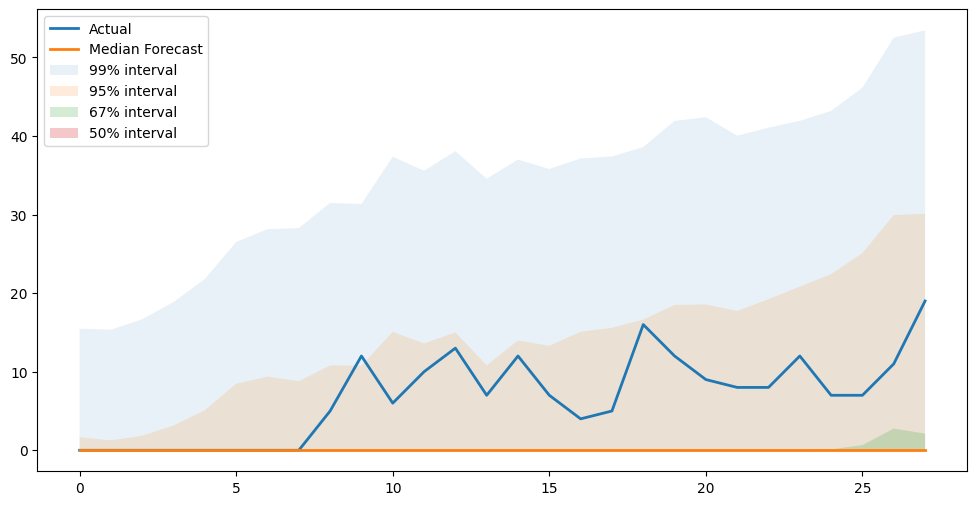

In [37]:
pred_tensor = raw_predictions["prediction"].detach().cpu().numpy()

# build a clean prediction dataframe
rows = []
batch_size, horizon, num_q = pred_tensor.shape

actuals = x["decoder_target"].detach().cpu().numpy()

for i in range(batch_size):
    series_id = index.iloc[i]["series_id"]

    for t in range(horizon):
        row = {
            "series_id": series_id,
            "time_idx": int(index.iloc[i]["time_idx"]) + t,
            "horizon_step": t + 1,
            "actual": actuals[i, t],
        }

        for j, q in enumerate(QUANTILES):
            row[f"q_{q}"] = pred_tensor[i, t, j]

        rows.append(row)

pred_df = pd.DataFrame(rows)

# add median / point forecast column for WRMSSE
pred_df["point_forecast"] = pred_df[f"q_{0.5}"]

print(pred_df.head())
print(pred_df.shape)

# PLOT ONE EXAMPLE FORECAST
example_series = pred_df["series_id"].iloc[0]
example_df = pred_df[pred_df["series_id"] == example_series].sort_values("horizon_step")

pred_cols = [f"q_{q}" for q in QUANTILES]
pred_matrix = example_df[pred_cols].values

plot_prediction_quantiles(
    actuals=example_df["actual"].values,
    preds=pred_matrix,
    quantiles=QUANTILES
)


In [38]:
# WSPL Helpers
def pinball_loss(y_true, y_pred, q):
    diff = y_true - y_pred
    return np.where(diff >= 0, q * diff, (1 - q) * (-diff))


def compute_series_scales(train_df, group_col="series_id", target_col="sales", time_col="time_idx"):
    scales = {}

    for series_id, g in train_df.sort_values([group_col, time_col]).groupby(group_col):
        y = g[target_col].values
        diffs = np.abs(np.diff(y))
        scale = diffs.mean() if len(diffs) > 0 else 0.0
        scales[series_id] = scale if scale > 0 else 1.0

    return scales


def compute_series_weights(
    train_df,
    price_col="sell_price",
    group_col="series_id",
    target_col="sales",
    time_col="time_idx",
    last_n=28
):
    weights = {}

    for series_id, g in train_df.sort_values([group_col, time_col]).groupby(group_col):
        tail = g.tail(last_n).copy()
        tail["revenue"] = tail[target_col] * tail[price_col]
        weights[series_id] = tail["revenue"].sum()

    total = sum(weights.values())
    if total == 0:
        n = len(weights)
        return {k: 1.0 / n for k in weights}

    return {k: v / total for k, v in weights.items()}


def compute_wspl(pred_df, quantiles, scales, weights):
    series_scores = []

    for series_id, g in pred_df.groupby("series_id"):
        scale = scales[series_id]
        weight = weights[series_id]

        q_scores = []
        for q in quantiles:
            y_true = g["actual"].values
            y_pred = g[f"q_{q}"].values
            pb = pinball_loss(y_true, y_pred, q)
            spl = pb.mean() / scale
            q_scores.append(spl)

        mean_q_score = np.mean(q_scores)
        series_scores.append(weight * mean_q_score)

    return float(np.sum(series_scores))



In [39]:
# COMPUTE WSPL
# training history only
train_history_df = data[data.time_idx <= training_cutoff].copy()

scales = compute_series_scales(train_history_df)
weights = compute_series_weights(train_history_df)

wspl_score = compute_wspl(pred_df, QUANTILES, scales, weights)

print("WSPL:", wspl_score)

WSPL: 0.22613982455890355


In [40]:
# Attach the metadata to prediction dataframe for WRMSSE
meta_cols = ["series_id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]

series_meta = data[meta_cols].drop_duplicates("series_id").copy()

pred_with_meta_df = pred_df.merge(series_meta, on="series_id", how="left")

print(pred_with_meta_df.head())

                     series_id  time_idx  horizon_step  actual       q_0.005  \
0  FOODS_1_004_CA_3_evaluation      1914             1     0.0  5.110674e-32   
1  FOODS_1_004_CA_3_evaluation      1915             2     0.0  6.892472e-33   
2  FOODS_1_004_CA_3_evaluation      1916             3     0.0  2.024766e-33   
3  FOODS_1_004_CA_3_evaluation      1917             4     0.0  1.162974e-33   
4  FOODS_1_004_CA_3_evaluation      1918             5     0.0  2.576579e-34   

        q_0.025       q_0.165        q_0.25         q_0.5        q_0.75  \
0  8.721740e-27  1.786898e-18  1.112117e-16  3.230198e-13  1.209480e-09   
1  5.728239e-28  2.593441e-19  1.719349e-17  7.875792e-14  3.777362e-10   
2  1.286920e-28  1.330876e-19  1.007173e-17  5.610385e-14  3.457256e-10   
3  6.198498e-29  1.492331e-19  1.273900e-17  8.203363e-14  6.316703e-10   
4  9.671765e-30  7.571538e-20  7.941574e-18  8.267955e-14  1.102019e-09   

        q_0.835   q_0.975    q_0.995  point_forecast      item_id  d

In [41]:
# Partial WRMSSE Helpers
def aggregate_forecasts(df, group_cols):
    if len(group_cols) == 0:
        agg = df.groupby("horizon_step", as_index=False)[["actual", "point_forecast"]].sum()
        agg["agg_id"] = "TOTAL"
        return agg

    agg = (
        df.groupby(group_cols + ["horizon_step"], as_index=False)[["actual", "point_forecast"]]
          .sum()
    )
    agg["agg_id"] = agg[group_cols].astype(str).agg("_".join, axis=1)
    return agg


def compute_rmsse_scales(train_long_df, group_cols, target_col="sales", time_col="time_idx"):
    scales = {}

    if len(group_cols) == 0:
        s = train_long_df.groupby(time_col)[target_col].sum().sort_index().values
        denom = np.mean(np.diff(s) ** 2) if len(s) > 1 else 0.0
        scales["TOTAL"] = denom if denom > 0 else 1.0
        return scales

    grouped = (
        train_long_df.groupby(group_cols + [time_col], as_index=False)[target_col]
        .sum()
    )

    for key, g in grouped.groupby(group_cols):
        y = g.sort_values(time_col)[target_col].values
        denom = np.mean(np.diff(y) ** 2) if len(y) > 1 else 0.0
        agg_id = "_".join(map(str, key)) if isinstance(key, tuple) else str(key)
        scales[agg_id] = denom if denom > 0 else 1.0

    return scales


def compute_wrmsse_weights(
    train_long_df,
    group_cols,
    price_col="sell_price",
    target_col="sales",
    time_col="time_idx",
    last_n=28
):
    weights = {}

    tail_threshold = train_long_df[time_col].max() - last_n + 1
    tail = train_long_df[train_long_df[time_col] >= tail_threshold].copy()
    tail["revenue"] = tail[target_col] * tail[price_col]

    if len(group_cols) == 0:
        weights["TOTAL"] = tail["revenue"].sum()
    else:
        grouped = tail.groupby(group_cols)["revenue"].sum()
        for key, value in grouped.items():
            agg_id = "_".join(map(str, key)) if isinstance(key, tuple) else str(key)
            weights[agg_id] = value

    total = sum(weights.values())
    if total == 0:
        n = len(weights)
        return {k: 1.0 / n for k in weights}

    return {k: v / total for k, v in weights.items()}


def compute_wrmsse_for_level(agg_pred_df, scales, weights):
    scores = []

    for agg_id, g in agg_pred_df.groupby("agg_id"):
        mse = np.mean((g["actual"].values - g["point_forecast"].values) ** 2)
        rmsse = np.sqrt(mse / scales[agg_id])
        scores.append(weights[agg_id] * rmsse)

    return float(np.sum(scores))


def compute_partial_wrmsse(pred_with_meta_df, train_long_df, levels):
    level_scores = []

    for group_cols in levels:
        agg_pred = aggregate_forecasts(pred_with_meta_df, group_cols)
        scales = compute_rmsse_scales(train_long_df, group_cols)
        weights = compute_wrmsse_weights(train_long_df, group_cols)
        score = compute_wrmsse_for_level(agg_pred, scales, weights)
        level_scores.append(score)

    return float(np.mean(level_scores))

In [42]:
# Compute Partial WRMSSE
levels = [
    [],            # total
    ["cat_id"],
    ["dept_id"],
    ["item_id"],
]

partial_wrmsse_score = compute_partial_wrmsse(
    pred_with_meta_df=pred_with_meta_df,
    train_long_df=train_history_df,
    levels=levels
)

print("Partial WRMSSE:", partial_wrmsse_score)

Partial WRMSSE: 0.522341729793704
